In [23]:
# Cell 1: Install all required libraries (run once, or when you recreate the server)

!pip install python-binance ta scikit-learn matplotlib pandas numpy --quiet


In [62]:
# Cell 2: Imports & basic setup

import pandas as pd
import numpy as np
import ta

from binance.client import Client
from binance.exceptions import BinanceAPIException

from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import warnings
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 100)

print("Imports loaded.")


Imports loaded.


In [63]:
# Cell 3: Training & scanner configs

CONFIG = {
    "symbol": "BTCUSDT",         # training symbol (USDT perpetual)
    "timeframe": "15m",          # Binance intervals: '1m','3m','5m','15m','1h','4h',...
    "limit": 1500,               # candles to pull for training
    "prediction_horizon": 3,     # candles ahead to look at
    "up_threshold": 0.002,       # +0.2% up move => LONG
    "down_threshold": -0.002,    # -0.2% down move => SHORT
    "train_split_ratio": 0.8,    # 80% train, 20% test
}

SCANNER_CONFIG = {
    "interval": "15m",        # same units as CONFIG["timeframe"]
    "limit": 250,
    "min_abs_score": 0.07,    # filter weak signals |score| < 0.07
    "top_n_symbols": 40,      # scan top 40 USDT perps by volume
    "show_top": 10            # display top 10 LONG and SHORT
}

SCANNER_TRADING_CONFIG = {
    "account_balance": 50.0, # example balance (for learning)
    "max_leverage": 10,
    "risk_per_trade": 0.02     # 2% risk per trade (theoretical)
}

print("Training & scanner CONFIGs loaded.")


Training & scanner CONFIGs loaded.


In [64]:
# Cell 4: Create a public Binance futures client (no API key needed for data)

# For data only we can use empty keys
client_public = Client(api_key="", api_secret="", testnet=False)

print("Public Binance client ready.")


Public Binance client ready.


In [65]:
# Cell 5: Fetch historical OHLCV from Binance USDT perpetual futures

def fetch_ohlcv(symbol="BTCUSDT", interval="15m", limit=1000):
    """
    Fetch OHLCV candles from Binance USDT-margined futures (PERPETUAL).
    Returns a clean pandas DataFrame indexed by timestamp.
    """
    try:
        klines = client_public.futures_klines(
            symbol=symbol,
            interval=interval,
            limit=limit
        )
    except BinanceAPIException as e:
        print("BinanceAPIException while fetching klines:", e)
        return None
    except Exception as e:
        print("Unknown error while fetching klines:", e)
        return None

    if not klines:
        print("No kline data returned for", symbol)
        return None

    df = pd.DataFrame(klines, columns=[
        "timestamp", "open", "high", "low", "close", "volume",
        "close_time", "quote_asset_volume", "num_trades",
        "taker_buy_base", "taker_buy_quote", "ignore"
    ])

    df = df[["timestamp", "open", "high", "low", "close", "volume"]]
    df["timestamp"] = pd.to_datetime(df["timestamp"], unit="ms")
    df[["open", "high", "low", "close", "volume"]] = df[["open", "high", "low", "close", "volume"]].astype(float)
    df.set_index("timestamp", inplace=True)

    return df

# Get training data for BTCUSDT futures
df_raw = fetch_ohlcv(CONFIG["symbol"], CONFIG["timeframe"], limit=CONFIG["limit"])
df_raw.tail()


,open,high,low,close,volume
timestamp,,,,,
2025-11-19 00:30:00,92267.4,92633.0,92013.6,92574.9,2300.636
2025-11-19 00:45:00,92574.8,92633.3,92373.3,92377.6,979.567
2025-11-19 01:00:00,92377.6,92405.9,91980.3,91998.2,2262.809
2025-11-19 01:15:00,91998.2,92617.2,91890.5,92396.1,1795.653
2025-11-19 01:30:00,92396.0,92482.0,92153.9,92298.7,1012.907


In [66]:
# Cell 6: Add indicators and engineered features

def add_indicators(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()

    # Basic returns
    df["return"] = df["close"].pct_change()

    # EMAs
    df["ema_9"] = df["close"].ewm(span=9, adjust=False).mean()
    df["ema_21"] = df["close"].ewm(span=21, adjust=False).mean()
    df["ema_50"] = df["close"].ewm(span=50, adjust=False).mean()
    df["ema_200"] = df["close"].ewm(span=200, adjust=False).mean()

    # RSI
    df["rsi_14"] = ta.momentum.rsi(df["close"], window=14)

    # ATR
    df["atr_14"] = ta.volatility.average_true_range(
        high=df["high"],
        low=df["low"],
        close=df["close"],
        window=14
    )

    # Volume MA
    df["vol_sma_20"] = df["volume"].rolling(window=20).mean()

    # Derived features
    df["ema_9_21_diff"] = df["ema_9"] - df["ema_21"]
    df["ema_21_50_diff"] = df["ema_21"] - df["ema_50"]
    df["atr_pct"] = df["atr_14"] / df["close"]
    df["vol_ratio"] = df["volume"] / df["vol_sma_20"]
    df["above_200_ema"] = (df["close"] > df["ema_200"]).astype(int)  # trend filter

    df.dropna(inplace=True)
    return df

df_feat = add_indicators(df_raw)
df_feat.tail()


,open,high,low,close,volume,return,ema_9,ema_21,ema_50,ema_200,rsi_14,atr_14,vol_sma_20,ema_9_21_diff,ema_21_50_diff,atr_pct,vol_ratio,above_200_ema
timestamp,,,,,,,,,,,,,,,,,,
2025-11-19 00:30:00,92267.4,92633.0,92013.6,92574.9,2300.636,0.003333,92686.857106,92797.206097,92584.866076,92970.274073,46.075170,397.273737,1188.23050,-110.348991,212.340021,0.004291,1.936187,0
2025-11-19 00:45:00,92574.8,92633.3,92373.3,92377.6,979.567,-0.002131,92625.005685,92759.060089,92576.737995,92964.376818,42.849767,387.468470,1168.65165,-134.054404,182.322093,0.004194,0.838203,0
2025-11-19 01:00:00,92377.6,92405.9,91980.3,91998.2,2262.809,-0.004107,92499.644548,92689.890990,92554.050231,92954.763119,37.424426,390.192151,1238.81275,-190.246442,135.840759,0.004241,1.826595,0
2025-11-19 01:15:00,91998.2,92617.2,91890.5,92396.1,1795.653,0.004325,92478.935638,92663.182718,92547.856104,92949.204282,45.253277,414.228426,1294.79855,-184.247080,115.326614,0.004483,1.386820,0
2025-11-19 01:30:00,92396.0,92482.0,92153.9,92298.7,1012.907,-0.001054,92442.888511,92630.047925,92538.085276,92942.731602,43.808434,408.076395,1287.38215,-187.159415,91.962649,0.004421,0.786796,0


In [67]:
# Cell 7: Label future moves and create train/test splits

def create_labels(
    df: pd.DataFrame,
    horizon: int = 3,
    up_th: float = 0.002,
    down_th: float = -0.002
) -> pd.DataFrame:
    df = df.copy()
    df["future_price"] = df["close"].shift(-horizon)
    df["future_return"] = (df["future_price"] - df["close"]) / df["close"]

    # 1 = long, -1 = short, 0 = neutral
    df["label"] = np.where(
        df["future_return"] > up_th, 1,
        np.where(df["future_return"] < down_th, -1, 0)
    )

    df.dropna(inplace=True)
    return df

df_labeled = create_labels(
    df_feat,
    horizon=CONFIG["prediction_horizon"],
    up_th=CONFIG["up_threshold"],
    down_th=CONFIG["down_threshold"]
)

df_labeled[["close", "future_price", "future_return", "label"]].tail(10)


,close,future_price,future_return,label
timestamp,,,,
2025-11-18 22:30:00,93223.2,92790.8,-0.004638,-1
2025-11-18 22:45:00,93119.6,92836.8,-0.003037,-1
2025-11-18 23:00:00,92788.7,92916.9,0.001382,0
2025-11-18 23:15:00,92790.8,92472.6,-0.003429,-1
2025-11-18 23:30:00,92836.8,92267.4,-0.006133,-1
2025-11-18 23:45:00,92916.9,92574.9,-0.003681,-1
2025-11-19 00:00:00,92472.6,92377.6,-0.001027,0
2025-11-19 00:15:00,92267.4,91998.2,-0.002918,-1
2025-11-19 00:30:00,92574.9,92396.1,-0.001931,0


In [68]:
# Cell 8: Build X, y and split into train/test

feature_cols = [
    "open", "high", "low", "close", "volume",
    "return",
    "ema_9", "ema_21", "ema_50", "ema_200",
    "rsi_14",
    "atr_14", "atr_pct",
    "vol_sma_20", "vol_ratio",
    "ema_9_21_diff", "ema_21_50_diff",
    "above_200_ema"
]

X = df_labeled[feature_cols].values
y = df_labeled["label"].values

split_idx = int(len(df_labeled) * CONFIG["train_split_ratio"])
X_train, X_test = X[:split_idx], X[split_idx:]
y_train, y_test = y[:split_idx], y[split_idx:]

print("Total samples:", len(df_labeled))
print("Train:", X_train.shape, "Test:", X_test.shape)


Total samples: 1478
Train: (1182, 18) Test: (296, 18)


In [69]:
# Cell 9: Train Gradient Boosting model and evaluate

model = GradientBoostingClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=3,
    subsample=0.9,
    random_state=42
)

model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print("Accuracy:", round(accuracy_score(y_test, y_pred), 4))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

# Map class labels to indices for predict_proba
class_idx = {c: i for i, c in enumerate(model.classes_)}
print("Class index mapping:", class_idx)


Accuracy: 0.4189

Classification Report:
              precision    recall  f1-score   support

          -1       0.80      0.04      0.08        95
           0       0.57      0.44      0.50       118
           1       0.34      0.82      0.48        83

    accuracy                           0.42       296
   macro avg       0.57      0.43      0.35       296
weighted avg       0.58      0.42      0.36       296

Confusion Matrix:
[[ 4 24 67]
 [ 1 52 65]
 [ 0 15 68]]
Class index mapping: {np.int64(-1): 0, np.int64(0): 1, np.int64(1): 2}


In [70]:
# Backtest the model with directional accuracy

bt_results = backtest_directional(
    df_labeled,
    model,
    feature_cols,
    horizon=CONFIG["prediction_horizon"]
)

bt_results


===== SIMPLE DIRECTIONAL BACKTEST =====
Total samples: 1478
Number of trades (non-neutral): 826
  Long trades: 489
  Short trades: 337
Total wins (directionally correct): 710
Win rate: 85.96 %
Average future return for LONG trades: 0.29 %
Average future return for SHORT trades (signed): 0.501 %
Average absolute future move when trading: 0.48 %


,open,high,low,close,volume,return,ema_9,ema_21,ema_50,ema_200,rsi_14,atr_14,vol_sma_20,ema_9_21_diff,ema_21_50_diff,atr_pct,vol_ratio,above_200_ema,future_price,future_return,label,pred
timestamp,,,,,,,,,,,,,,,,,,,,,,
2025-11-03 15:30:00,105925.5,106583.2,105500.0,106063.1,13479.383,0.001292,107093.712763,107303.784225,107226.612809,107032.851507,30.704505,565.134249,2624.48885,-210.071462,77.171416,0.005328,5.136003,0,106328.0,0.002498,1,1
2025-11-03 15:45:00,106063.1,106267.2,105617.3,105718.8,4092.649,-0.003246,106818.730210,107159.694750,107167.482895,107019.776368,27.728823,571.188945,2678.30430,-340.964540,-7.788145,0.005403,1.528075,0,106452.4,0.006939,1,1
2025-11-03 16:00:00,105718.8,106165.5,105300.0,106045.8,7677.032,0.003093,106664.144168,107058.431591,107123.495330,107010.085061,34.246580,592.211163,2954.43015,-394.287423,-65.063740,0.005584,2.598481,0,106644.0,0.005641,1,1
2025-11-03 16:15:00,106045.8,106555.0,105766.4,106328.0,4619.182,0.002661,106596.915334,106992.028719,107092.299435,107003.298145,39.331566,606.238937,3125.90715,-395.113384,-100.270716,0.005702,1.477709,0,106796.8,0.004409,1,1
2025-11-03 16:30:00,106328.0,106604.1,106183.7,106452.4,2840.544,0.001170,106568.012268,106942.971562,107067.205339,106997.816571,41.480009,592.964728,3235.47170,-374.959295,-124.233777,0.005570,0.877938,0,107045.5,0.005572,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-11-18 23:45:00,92836.7,93003.0,92703.5,92916.9,532.837,0.000863,92915.234973,92914.844416,92603.375717,92986.464760,51.147485,347.359005,914.37330,0.390557,311.468699,0.003738,0.582735,0,92574.9,-0.003681,-1,1
2025-11-19 00:00:00,92916.8,92944.8,92459.0,92472.6,1538.215,-0.004782,92826.707978,92874.640378,92598.247257,92981.351678,42.718831,357.247648,946.76070,-47.932400,276.393120,0.003863,1.624714,0,92377.6,-0.001027,0,0
2025-11-19 00:15:00,92472.7,92517.0,91838.6,92267.4,3802.884,-0.002219,92714.846382,92819.436707,92585.272855,92974.247681,39.482697,380.187101,1112.38270,-104.590325,234.163852,0.004120,3.418683,0,91998.2,-0.002918,-1,1


In [77]:
# Cell 10: Get top USDT perpetual futures on Binance by 24h quote volume

def get_top_usdt_perp_binance(n=40):
    """
    Get top N USDT-margined PERPETUAL futures on Binance by 24h quote volume.
    """

    # Exchange info to filter USDT perps
    info = client_public.futures_exchange_info()
    symbols_info = info["symbols"]

    usdt_perps = [
        s["symbol"]
        for s in symbols_info
        if s.get("quoteAsset") == "USDT"
        and s.get("contractType") == "PERPETUAL"
        and s.get("status") == "TRADING"
    ]

    # 24h ticker data
    tickers = client_public.futures_ticker()  # list of dicts

    candidates = []
    vol_map = {}
    chg_map = {}

    for t in tickers:
        sym = t["symbol"]
        if sym in usdt_perps:
            # futures 24h ticker has "quoteVolume" and "priceChangePercent"
            quote_vol_24h = float(t.get("quoteVolume", 0.0))
            chg_24h = float(t.get("priceChangePercent", 0.0))
            candidates.append((sym, quote_vol_24h, chg_24h))

    ranked = sorted(candidates, key=lambda x: x[1], reverse=True)
    top = ranked[:n]

    symbols = [x[0] for x in top]
    vol_map = {x[0]: x[1] for x in top}
    chg_map = {x[0]: x[2] for x in top}

    return symbols, vol_map, chg_map

futures_symbols_top, futures_vol_map, futures_chg_map = get_top_usdt_perp_binance(
    SCANNER_CONFIG["top_n_symbols"]
)

print("Top futures symbols count:", len(futures_symbols_top))
futures_symbols_top[:10]


Top futures symbols count: 40


['BTCUSDT',
 'ETHUSDT',
 'SOLUSDT',
 'ZECUSDT',
 'XRPUSDT',
 'DOGEUSDT',
 'BNBUSDT',
 'ASTERUSDT',
 'XANUSDT',
 'RESOLVUSDT']

In [78]:
# Cell 11: Prepare per-symbol data (features + last row for prediction)

def get_prepared_symbol_data(symbol, interval, limit):
    """
    For scanner: fetch OHLCV for a symbol,
    add indicators, and return (last_row, X_live) or (None, None).
    """
    df = fetch_ohlcv(symbol, interval, limit)
    if df is None or len(df) < 100:
        return None, None

    df_feat_sym = add_indicators(df)
    if df_feat_sym.empty or len(df_feat_sym) < 20:
        return None, None

    last = df_feat_sym.tail(1)
    X_live = last[feature_cols].values
    return last, X_live

# Sanity check on one symbol
last_row_sample, X_sample = get_prepared_symbol_data(
    futures_symbols_top[0],
    SCANNER_CONFIG["interval"],
    SCANNER_CONFIG["limit"]
)
last_row_sample


,open,high,low,close,volume,return,ema_9,ema_21,ema_50,ema_200,rsi_14,atr_14,vol_sma_20,ema_9_21_diff,ema_21_50_diff,atr_pct,vol_ratio,above_200_ema
timestamp,,,,,,,,,,,,,,,,,,
2025-11-19 01:45:00,92340.1,92352.8,92309.0,92310.0,23.888,-0.000326,92422.934808,92604.374147,92530.68324,92857.287134,43.937839,382.056653,1223.1459,-181.439338,73.690907,0.004139,0.01953,0


In [79]:
# Cell 12: Compute ML signal (LONG/SHORT/NEUTRAL) for one symbol

def compute_symbol_signal(symbol, interval="15m", limit=250):
    """
    For a given futures symbol:
    - fetch OHLCV & indicators
    - run ML model
    - produce signal, probabilities, score
    """
    try:
        last_row, X_live = get_prepared_symbol_data(symbol, interval, limit)
        if last_row is None or X_live is None:
            return None

        pred = model.predict(X_live)[0]
        proba = model.predict_proba(X_live)[0]

        idx_long = class_idx.get(1, None)
        idx_short = class_idx.get(-1, None)

        prob_long = proba[idx_long] if idx_long is not None else 0.0
        prob_short = proba[idx_short] if idx_short is not None else 0.0

        score = prob_long - prob_short  # >0 = bullish, <0 = bearish

        signal_map = {1: "LONG", -1: "SHORT", 0: "NEUTRAL"}

        info = {
            "symbol": symbol,
            "time": last_row.index[-1],
            "signal": signal_map.get(int(pred), "NEUTRAL"),
            "pred": int(pred),
            "prob_long": float(prob_long),
            "prob_short": float(prob_short),
            "score": float(score),
            "price": float(last_row["close"].iloc[0]),
            "atr": float(last_row["atr_14"].iloc[0]),
            "above_200_ema": int(last_row["above_200_ema"].iloc[0]),
            "quote_volume_24h": float(futures_vol_map.get(symbol, 0.0)),
            "price_change_24h": float(futures_chg_map.get(symbol, 0.0)),
        }

        return info

    except Exception as e:
        print(f"Error computing signal for {symbol}:", e)
        return None

test_signal = compute_symbol_signal(
    futures_symbols_top[0],
    SCANNER_CONFIG["interval"],
    SCANNER_CONFIG["limit"]
)
test_signal


{'symbol': 'BTCUSDT',
 'time': Timestamp('2025-11-19 01:45:00'),
 'signal': 'LONG',
 'pred': 1,
 'prob_long': 0.837330608382785,
 'prob_short': 0.010177312794803418,
 'score': 0.8271532955879816,
 'price': 92310.0,
 'atr': 382.0566529208168,
 'above_200_ema': 0,
 'quote_volume_24h': 21319164550.49,
 'price_change_24h': 0.479}

In [81]:
# Cell 13: Scan many futures symbols and build a ranked signals DataFrame

def scan_futures_market(
    symbols,
    interval="15m",
    limit=250,
    min_abs_score=0.07
):
    """
    Scans a list of futures symbols:
    - compute signal & score per symbol
    - filter by |score|
    - return sorted DataFrame
    """
    results = []

    for sym in symbols:
        info = compute_symbol_signal(sym, interval=interval, limit=limit)
        if info is None:
            continue

        if abs(info["score"]) < min_abs_score:
            continue

        results.append(info)

    if not results:
        print("No strong signals found.")
        return pd.DataFrame()

    df_res = pd.DataFrame(results)
    df_res = df_res.sort_values(by="score", ascending=False).reset_index(drop=True)
    return df_res

scanner_results = scan_futures_market(
    futures_symbols_top,
    interval=SCANNER_CONFIG["interval"],
    limit=SCANNER_CONFIG["limit"],
    min_abs_score=SCANNER_CONFIG["min_abs_score"]
)

scanner_results.head(10)


,symbol,time,signal,pred,prob_long,prob_short,score,price,atr,above_200_ema,quote_volume_24h,price_change_24h
0,PAXGUSDT,2025-11-19 01:45:00,LONG,1,0.926621,0.054112,0.872508,4057.2000,6.391273,1,1.989674e+08,0.909
1,TAOUSDT,2025-11-19 01:45:00,LONG,1,0.892407,0.029850,0.862557,329.8900,2.589976,1,1.910978e+08,3.597
2,ZENUSDT,2025-11-19 01:45:00,LONG,1,0.894879,0.038825,0.856055,15.9590,0.284532,0,4.086650e+08,3.535
3,XPLUSDT,2025-11-19 01:45:00,LONG,1,0.902844,0.056607,0.846238,0.2494,0.003534,1,4.065432e+08,0.930
4,FARTCOINUSDT,2025-11-19 01:45:00,LONG,1,0.897865,0.059620,0.838245,0.2547,0.002656,1,1.365088e+08,5.233
5,BTCUSDT,2025-11-19 01:45:00,LONG,1,0.837598,0.010152,0.827446,92303.4000,382.456653,0,2.131916e+10,0.479
6,ZECUSDT,2025-11-19 01:45:00,LONG,1,0.864437,0.046742,0.817695,604.5500,8.603908,0,3.263185e+09,-1.626
7,LINKUSDT,2025-11-19 01:45:00,LONG,1,0.883508,0.085081,0.798428,13.6970,0.088591,1,3.106939e+08,2.731
8,ASTERUSDT,2025-11-19 01:45:00,LONG,1,0.866372,0.083953,0.782418,1.3905,0.016535,1,1.002084e+09,13.247
9,DASHUSDT,2025-11-19 01:45:00,LONG,1,0.837538,0.056160,0.781378,77.0000,0.986621,0,2.033855e+08,-0.528


In [82]:
# Cell 14: Pretty print top LONG and SHORT candidates

from IPython.display import display

def show_top_signals(scanner_df, top_n=10):
    if scanner_df.empty:
        print("No signals to show.")
        return

    longs = scanner_df[scanner_df["signal"] == "LONG"].head(top_n)
    shorts = scanner_df[scanner_df["signal"] == "SHORT"].tail(top_n)  # more negative scores at bottom

    print("===== TOP LONG CANDIDATES =====")
    display(
        longs[[
            "symbol","time","price",
            "prob_long","prob_short","score",
            "quote_volume_24h","price_change_24h","atr","above_200_ema"
        ]]
    )

    print("===== TOP SHORT CANDIDATES =====")
    display(
        shorts[[
            "symbol","time","price",
            "prob_long","prob_short","score",
            "quote_volume_24h","price_change_24h","atr","above_200_ema"
        ]]
    )

show_top_signals(scanner_results, top_n=SCANNER_CONFIG["show_top"])


===== TOP LONG CANDIDATES =====


,symbol,time,price,prob_long,prob_short,score,quote_volume_24h,price_change_24h,atr,above_200_ema
0,PAXGUSDT,2025-11-19 01:45:00,4057.2000,0.926621,0.054112,0.872508,1.989674e+08,0.909,6.391273,1
1,TAOUSDT,2025-11-19 01:45:00,329.8900,0.892407,0.029850,0.862557,1.910978e+08,3.597,2.589976,1
2,ZENUSDT,2025-11-19 01:45:00,15.9590,0.894879,0.038825,0.856055,4.086650e+08,3.535,0.284532,0
3,XPLUSDT,2025-11-19 01:45:00,0.2494,0.902844,0.056607,0.846238,4.065432e+08,0.930,0.003534,1
4,FARTCOINUSDT,2025-11-19 01:45:00,0.2547,0.897865,0.059620,0.838245,1.365088e+08,5.233,0.002656,1
5,BTCUSDT,2025-11-19 01:45:00,92303.4000,0.837598,0.010152,0.827446,2.131916e+10,0.479,382.456653,0
6,ZECUSDT,2025-11-19 01:45:00,604.5500,0.864437,0.046742,0.817695,3.263185e+09,-1.626,8.603908,0
7,LINKUSDT,2025-11-19 01:45:00,13.6970,0.883508,0.085081,0.798428,3.106939e+08,2.731,0.088591,1
8,ASTERUSDT,2025-11-19 01:45:00,1.3905,0.866372,0.083953,0.782418,1.002084e+09,13.247,0.016535,1
9,DASHUSDT,2025-11-19 01:45:00,77.0000,0.837538,0.056160,0.781378,2.033855e+08,-0.528,0.986621,0


===== TOP SHORT CANDIDATES =====


,symbol,time,price,prob_long,prob_short,score,quote_volume_24h,price_change_24h,atr,above_200_ema


In [83]:
# Cell 15: Example position sizing logic (for learning only)

def example_position_size(price, atr, cfg=SCANNER_TRADING_CONFIG):
    """
    Example educational function:
    - risk_per_trade % of balance
    - stop distance ~ 1 * ATR
    - apply leverage
    """
    balance = cfg["account_balance"]
    risk = cfg["risk_per_trade"]
    lev = cfg["max_leverage"]

    if atr <= 0 or np.isnan(atr):
        return 0.0, 0.0

    risk_amount = balance * risk
    stop_distance = atr
    size = risk_amount / stop_distance   # size in base asset
    notional = size * price * lev        # with leverage

    return size, notional

# Example: compute position size for the top long candidate
if not scanner_results.empty:
    best_long = scanner_results[scanner_results["signal"] == "LONG"].head(1)
    if not best_long.empty:
        row = best_long.iloc[0]
        size, notional = example_position_size(row["price"], row["atr"])
        print("Example LONG candidate:", row["symbol"])
        print("Price:", row["price"])
        print("ATR:", row["atr"])
        print("Example size (base asset):", round(size, 4))
        print("Example notional with leverage:", round(notional, 2), "USDT (educational)")


Example LONG candidate: PAXGUSDT
Price: 4057.2
ATR: 6.3912731595352055
Example size (base asset): 0.1565
Example notional with leverage: 6348.03 USDT (educational)


In [84]:
# Cell 16: LIVE TRADING TEMPLATE (Binance USDT futures)
# -------------------------------------------------------------------
# This is for FUTURE USE on a server with REAL API KEYS.
# It is for EDUCATIONAL STRUCTURE ONLY.
# DO NOT paste your keys in a notebook you share with anyone.

API_KEY = "YOUR_BINANCE_API_KEY"
API_SECRET = "YOUR_BINANCE_API_SECRET"

def get_auth_client(testnet=False):
    """
    Return an authenticated Binance client.
    Set testnet=True if you want to trade on testnet endpoints.
    """
    return Client(api_key=API_KEY, api_secret=API_SECRET, testnet=testnet)

def get_futures_balance_usdt(client_auth):
    balances = client_auth.futures_account_balance()
    for b in balances:
        if b["asset"] == "USDT":
            return float(b["balance"])
    return 0.0

def place_futures_market_order(client_auth, symbol, side, quantity):
    """
    side: 'BUY' or 'SELL'
    quantity: base asset amount (e.g., 0.01 BTC)
    """
    print(f"[ORDER] {side} {quantity} {symbol} (MARKET)")
    order = client_auth.futures_create_order(
        symbol=symbol,
        side=side,
        type="MARKET",
        quantity=quantity
    )
    return order

# Example skeleton for a live loop (KEEP COMMENTED for now)
#
# import time
#
# def live_trading_loop():
#     client_auth = get_auth_client(testnet=False)
#     while True:
#         # 1) refresh top futures
#         symbols, vol_map, chg_map = get_top_usdt_perp_binance(SCANNER_CONFIG["top_n_symbols"])
#         global futures_vol_map, futures_chg_map
#         futures_vol_map, futures_chg_map = vol_map, chg_map
#
#         # 2) scan market
#         df_scan = scan_futures_market(
#             symbols,
#             interval=SCANNER_CONFIG["interval"],
#             limit=SCANNER_CONFIG["limit"],
#             min_abs_score=SCANNER_CONFIG["min_abs_score"]
#         )
#
#         # 3) choose best symbol(s) and compute size
#         #    (use example_position_size + your own rules)
#
#         # 4) send orders via place_futures_market_order(...)
#
#         # 5) sleep, then repeat
#         time.sleep(60)
#
# -------------------------------------------------------------------
print("Live trading template defined (do NOT run until you're ready).")


Live trading template defined (do NOT run until you're ready).


In [85]:
# Cell 17: Risk & safety settings for trading logic (simulation / testnet)

RISK_CONFIG = {
    "max_leverage": 10,        # you said 10x
    "risk_per_trade": 0.02,    # risk 2% of equity per trade
    "min_atr_pct": 0.001,      # skip if ATR is extremely tiny (<0.1% of price)
    "max_atr_pct": 0.05,       # skip if ATR is huge (>5% of price) = too volatile
    "min_quote_volume_24h": 5_000_000,  # skip illiquid stuff
    "trend_filter_long": True, # only long if above EMA200
    "trend_filter_short": True,# only short if below EMA200
    "cooldown_minutes": 30,    # do not re-enter same symbol too quickly
}
print("Risk config loaded.")


Risk config loaded.


In [86]:
# Cell 18: Position sizing with leverage and safety checks (simulation/paper)

from datetime import datetime, timedelta

# To track last trade time per symbol for cooldown
last_trade_time = {}  # symbol -> datetime

def compute_position_size(price, atr, balance, cfg=RISK_CONFIG):
    """
    Compute position size based on:
    - % of balance risked
    - stop distance ≈ 1 * ATR
    - leverage
    Returns: (qty, notional, stop_distance)
    """
    if atr <= 0 or np.isnan(atr):
        return 0.0, 0.0, 0.0

    atr_pct = atr / price
    if atr_pct < cfg["min_atr_pct"] or atr_pct > cfg["max_atr_pct"]:
        # Too low or too high volatility -> skip
        return 0.0, 0.0, atr

    risk_amount = balance * cfg["risk_per_trade"]
    stop_distance = atr  # you can make this 1.5 * ATR, 2 * ATR, etc.
    if stop_distance <= 0:
        return 0.0, 0.0, 0.0

    # Size in base asset
    qty = risk_amount / stop_distance

    # Apply leverage
    notional = qty * price * cfg["max_leverage"]

    return float(qty), float(notional), float(stop_distance)


def is_symbol_allowed_to_trade(row, cfg=RISK_CONFIG, now=None):
    """
    Check trend filters, liquidity, cooldown, etc.
    row: a row from scanner_results (one symbol's signal info)
    """
    if now is None:
        now = datetime.utcnow()

    sym = row["symbol"]

    # Liquidity filter
    if row["quote_volume_24h"] < cfg["min_quote_volume_24h"]:
        return False, "Low 24h quote volume"

    # Trend filter
    if row["signal"] == "LONG" and cfg["trend_filter_long"]:
        if row["above_200_ema"] != 1:
            return False, "LONG but not above EMA200"

    if row["signal"] == "SHORT" and cfg["trend_filter_short"]:
        if row["above_200_ema"] != 0:
            return False, "SHORT but not below EMA200"

    # Cooldown filter
    last_t = last_trade_time.get(sym, None)
    if last_t is not None:
        if now - last_t < timedelta(minutes=cfg["cooldown_minutes"]):
            return False, "Cooldown active"

    return True, "OK"


print("Position sizing & safety helpers defined.")


Position sizing & safety helpers defined.


In [87]:
# Cell 19: Simulate which symbols you would trade now (paper decision)

def paper_trading_decision(scanner_df, account_balance=1000.0):
    """
    For each signal in scanner_results:
      - apply filters
      - compute size
      - print what the bot WOULD do (no real order)
    """
    if scanner_df.empty:
        print("No scanner results available.")
        return

    now = datetime.utcnow()
    actions = []

    for idx, row in scanner_df.iterrows():
        allowed, reason = is_symbol_allowed_to_trade(row, now=now)
        if not allowed:
            # You can print filtered-out reasons for debugging:
            # print(f"[SKIP] {row['symbol']} - {reason}")
            continue

        qty, notional, stop_dist = compute_position_size(
            price=row["price"],
            atr=row["atr"],
            balance=account_balance,
            cfg=RISK_CONFIG
        )

        if qty <= 0 or notional <= 0:
            # print(f"[SKIP] {row['symbol']} - invalid size")
            continue

        actions.append({
            "symbol": row["symbol"],
            "signal": row["signal"],
            "price": row["price"],
            "qty": qty,
            "notional": notional,
            "atr": row["atr"],
            "stop_distance": stop_dist,
            "quote_volume_24h": row["quote_volume_24h"],
            "score": row["score"],
        })

    if not actions:
        print("No valid trades passed all filters.")
        return

    actions_df = pd.DataFrame(actions)
    display(actions_df.sort_values(by="score", ascending=False))

    return actions_df

# Example: use scanner_results we already computed
paper_trades = paper_trading_decision(scanner_results, account_balance=SCANNER_TRADING_CONFIG["account_balance"])


,symbol,signal,price,qty,notional,atr,stop_distance,quote_volume_24h,score
0,PAXGUSDT,LONG,4057.200000,0.156463,6348.030977,6.391273,6.391273,1.989674e+08,0.872508
1,TAOUSDT,LONG,329.890000,0.386104,1273.718170,2.589976,2.589976,1.910978e+08,0.862557
2,XPLUSDT,LONG,0.249400,282.960452,705.703367,0.003534,0.003534,4.065432e+08,0.846238
3,FARTCOINUSDT,LONG,0.254700,376.560341,959.099189,0.002656,0.002656,1.365088e+08,0.838245
4,LINKUSDT,LONG,13.697000,11.287770,1546.085836,0.088591,0.088591,3.106939e+08,0.798428
5,ASTERUSDT,LONG,1.390500,60.477794,840.943722,0.016535,0.016535,1.002084e+09,0.782418
6,BCHUSDT,LONG,508.300000,0.212806,1081.691290,4.699123,4.699123,2.784683e+08,0.762946
7,CROSSUSDT,LONG,0.124190,398.145514,494.456914,0.002512,0.002512,1.497877e+08,0.740823
8,FILUSDT,LONG,1.995000,47.281124,943.258434,0.021150,0.021150,4.361744e+08,0.712679
9,BNBUSDT,LONG,935.950000,0.298820,2796.808671,3.346493,3.346493,1.012040e+09,0.706968


In [88]:
# Cell 20: Simple directional backtest to estimate win rate on historical data

def backtest_directional(df_labeled, model, feature_cols, horizon=3):
    """
    Very simple backtest:
    - Use model to predict on entire labeled dataset
    - Compare against future_return sign
    - Compute win rate, avg return, etc.
    NOTE: This ignores transaction costs, slippage, funding, etc.
    """
    df_bt = df_labeled.copy()

    X_all = df_bt[feature_cols].values
    preds = model.predict(X_all)
    df_bt["pred"] = preds

    # Already present from labeling:
    # df_bt["future_return"]

    # Determine if each trade is a 'win' or 'loss'
    # For LONG -> win if future_return > 0
    # For SHORT -> win if future_return < 0
    # For NEUTRAL -> no trade

    is_trade = df_bt["pred"] != 0
    long_trades = df_bt["pred"] == 1
    short_trades = df_bt["pred"] == -1

    long_wins = (long_trades) & (df_bt["future_return"] > 0)
    short_wins = (short_trades) & (df_bt["future_return"] < 0)

    n_trades = is_trade.sum()
    n_long = long_trades.sum()
    n_short = short_trades.sum()
    n_wins = long_wins.sum() + short_wins.sum()

    win_rate = n_wins / n_trades if n_trades > 0 else 0.0

    avg_ret_long = df_bt.loc[long_trades, "future_return"].mean() if n_long > 0 else 0.0
    avg_ret_short = -df_bt.loc[short_trades, "future_return"].mean() if n_short > 0 else 0.0  # invert for shorts
    avg_abs_ret = df_bt.loc[is_trade, "future_return"].abs().mean() if n_trades > 0 else 0.0

    print("===== SIMPLE DIRECTIONAL BACKTEST =====")
    print("Total samples:", len(df_bt))
    print("Number of trades (non-neutral):", n_trades)
    print("  Long trades:", n_long)
    print("  Short trades:", n_short)
    print("Total wins (directionally correct):", n_wins)
    print("Win rate:", round(win_rate * 100, 2), "%")
    print("Average future return for LONG trades:", round(avg_ret_long * 100, 3), "%")
    print("Average future return for SHORT trades (signed):", round(avg_ret_short * 100, 3), "%")
    print("Average absolute future move when trading:", round(avg_abs_ret * 100, 3), "%")

    return df_bt

bt_results = backtest_directional(df_labeled, model, feature_cols, horizon=CONFIG["prediction_horizon"])


===== SIMPLE DIRECTIONAL BACKTEST =====
Total samples: 1478
Number of trades (non-neutral): 826
  Long trades: 489
  Short trades: 337
Total wins (directionally correct): 710
Win rate: 85.96 %
Average future return for LONG trades: 0.29 %
Average future return for SHORT trades (signed): 0.501 %
Average absolute future move when trading: 0.48 %


In [89]:
# ============================
# 21 REAL BINANCE FUTURES CLIENT
# ============================

from binance.client import Client
from binance.enums import *


REAL_API_KEY = "q2s7h4eHcv3jKSVgeNeu1tzQY4Gcir3w9osN0qyVSewdlTVUL2XZHXXXLVmp9zRX" 
REAL_API_SECRET = "fQIMICFj6XhUHFWXo7l3orolPJ6J1rT8yoTuVo3x4tn1t8DWJYUgd0H5bvn2snAx"
def get_real_futures_client():
    """
    Connect to REAL Binance USDT-M Futures.
    """
    client = Client(
        api_key=REAL_API_KEY,
        api_secret=REAL_API_SECRET
    )
    # REAL Futures endpoint
    client.FUTURES_URL = "https://fapi.binance.com/fapi"
    return client

client = get_real_futures_client()

# Test balance
try:
    print(client.futures_account_balance())
    print("REAL futures client connected successfully!")
except Exception as e:
    print("Connection error:", e)


[{'accountAlias': 'SguXXquXsRsRFzXq', 'asset': 'FDUSD', 'balance': '0.00000000', 'crossWalletBalance': '0.00000000', 'crossUnPnl': '0.00000000', 'availableBalance': '0.00000000', 'maxWithdrawAmount': '0.00000000', 'marginAvailable': True, 'updateTime': 0}, {'accountAlias': 'SguXXquXsRsRFzXq', 'asset': 'LDUSDT', 'balance': '0.00000000', 'crossWalletBalance': '0.00000000', 'crossUnPnl': '0.00000000', 'availableBalance': '0.00000000', 'maxWithdrawAmount': '0.00000000', 'marginAvailable': True, 'updateTime': 0}, {'accountAlias': 'SguXXquXsRsRFzXq', 'asset': 'BFUSD', 'balance': '0.00000000', 'crossWalletBalance': '0.00000000', 'crossUnPnl': '0.00000000', 'availableBalance': '0.00000000', 'maxWithdrawAmount': '0.00000000', 'marginAvailable': True, 'updateTime': 0}, {'accountAlias': 'SguXXquXsRsRFzXq', 'asset': 'BNB', 'balance': '0.00000000', 'crossWalletBalance': '0.00000000', 'crossUnPnl': '0.00000000', 'availableBalance': '0.00000000', 'maxWithdrawAmount': '0.00000000', 'marginAvailable': 

In [90]:
# Cell A – Real Binance Futures Client (EDUCATIONAL)
from binance.client import Client

REAL_API_KEY = "q2s7h4eHcv3jKSVgeNeu1tzQY4Gcir3w9osN0qyVSewdlTVUL2XZHXXXLVmp9zRX" 
REAL_API_SECRET = "fQIMICFj6XhUHFWXo7l3orolPJ6J1rT8yoTuVo3x4tn1t8DWJYUgd0H5bvn2snAx"
def get_real_futures_client():
    """
    Connects to REAL Binance Futures.
    """
    client = Client(
        REAL_API_KEY,
        REAL_API_SECRET
    )
    
    # REAL futures base endpoint
    client.FUTURES_URL = "https://fapi.binance.com/fapi"
    
    return client

print("Real Binance Futures client ready.")


Real Binance Futures client ready.


In [91]:
# ========================================
# REAL Futures: leverage & margin settings
# ========================================

def set_symbol_leverage_real(client, symbol, leverage=10):
    try:
        res = client.futures_change_leverage(
            symbol=symbol,
            leverage=int(leverage)
        )
        print(f"[REAL LEVERAGE] {symbol}: {res['leverage']}x")
    except Exception as e:
        print(f"[LEV ERROR] {symbol}:", e)

def set_symbol_margin_real(client, symbol, isolated=True):
    try:
        res = client.futures_change_margin_type(
            symbol=symbol,
            marginType="ISOLATED" if isolated else "CROSSED"
        )
        print(f"[REAL MARGIN] {symbol} set to", "ISOLATED" if isolated else "CROSSED")
    except Exception as e:
        if "No need to change margin type" in str(e):
            print(f"[REAL MARGIN] {symbol} already correct")
        else:
            print(f"[MARGIN ERROR] {symbol}:", e)


In [92]:
# Cell C: Open futures position + attach SL/TP (testnet, educational)

import math

def round_qty(symbol, qty, client):
    """
    Round quantity to allowed step size for the symbol on futures.
    """
    info = client.futures_exchange_info()
    for s in info["symbols"]:
        if s["symbol"] == symbol:
            for f in s["filters"]:
                if f["filterType"] == "LOT_SIZE":
                    step = float(f["stepSize"])
                    # Avoid division by zero
                    if step <= 0:
                        return qty
                    # floor to valid step
                    return math.floor(qty / step) * step
    return qty

def place_testnet_trade_with_sl_tp(row, account_balance, rr=2.0):
    """
    Given one scanner row (symbol + signal + price + atr + etc),
    decide side, compute qty, set leverage/margin, send MARKET order + SL/TP.
    rr = reward:risk ratio for TP (e.g., 2.0 → TP at 2*SL distance)
    """

    client = get_testnet_client()
    symbol = row["symbol"]
    signal = row["signal"]
    price = row["price"]
    atr = row["atr"]

    # Check filters again (trend, volume, cooldown, etc.)
    allowed, reason = is_symbol_allowed_to_trade(row)
    if not allowed:
        print(f"[SKIP] {symbol} - {reason}")
        return None

    # Compute size
    qty, notional, stop_dist = compute_position_size(
        price=price,
        atr=atr,
        balance=account_balance,
        cfg=RISK_CONFIG
    )

    if qty <= 0 or notional <= 0:
        print(f"[SKIP] {symbol} - invalid qty or notional")
        return None

    # Round quantity to valid step
    qty_rounded = round_qty(symbol, qty, client)
    if qty_rounded <= 0:
        print(f"[SKIP] {symbol} - qty too small after rounding")
        return None

    # Set isolated margin & leverage
    set_symbol_margin_isolated(client, symbol, isolated=True)
    set_symbol_leverage(client, symbol, leverage=RISK_CONFIG["max_leverage"])

    # Decide side & SL/TP prices
    if signal == "LONG":
        side = "BUY"
        sl_price = price - stop_dist      # below entry
        tp_price = price + stop_dist * rr # above entry
    elif signal == "SHORT":
        side = "SELL"
        sl_price = price + stop_dist      # above entry
        tp_price = price - stop_dist * rr # below entry
    else:
        print(f"[SKIP] {symbol} - NEUTRAL signal")
        return None

    print(f"\n[TRADE] {symbol} {signal} | price={price} | qty={qty_rounded}")
    print(f"        SL={sl_price} | TP={tp_price}")

    # 1) MAIN MARKET ORDER
    try:
        order = client.futures_create_order(
            symbol=symbol,
            side=side,
            type="MARKET",
            quantity=qty_rounded
        )
        print("[ORDER] Market placed:", order["orderId"])
    except Exception as e:
        print("[ERROR] Failed to place market order:", e)
        return None

    # 2) STOP LOSS ORDER (STOP_MARKET)
    try:
        sl_side = "SELL" if side == "BUY" else "BUY"
        sl_order = client.futures_create_order(
            symbol=symbol,
            side=sl_side,
            type="STOP_MARKET",
            stopPrice=round(sl_price, 2),
            closePosition=True,
            timeInForce="GTC"
        )
        print("[SL] Stop loss order placed:", sl_order["orderId"])
    except Exception as e:
        print("[SL ERROR] Failed to place SL:", e)

    # 3) TAKE PROFIT ORDER (TAKE_PROFIT_MARKET)
    try:
        tp_side = "SELL" if side == "BUY" else "BUY"
        tp_order = client.futures_create_order(
            symbol=symbol,
            side=tp_side,
            type="TAKE_PROFIT_MARKET",
            stopPrice=round(tp_price, 2),
            closePosition=True,
            timeInForce="GTC"
        )
        print("[TP] Take profit order placed:", tp_order["orderId"])
    except Exception as e:
        print("[TP ERROR] Failed to place TP:", e)

    # Mark last trade time for cooldown
    from datetime import datetime
    last_trade_time[symbol] = datetime.utcnow()

    return {
        "symbol": symbol,
        "side": side,
        "qty": qty_rounded,
        "entry_price": price,
        "sl_price": sl_price,
        "tp_price": tp_price
    }

print("Trade execution with SL/TP helper ready.")


Trade execution with SL/TP helper ready.


In [93]:
# Cell D: Auto trading loop on TESTNET (educational only)

import time

def auto_trading_loop_testnet(
    cycles=10,
    sleep_seconds=60,
    account_balance=1000.0,
    min_abs_score=None
):
    """
    Auto-trading loop:
      - Refresh top futures
      - Scan market
      - Choose best candidate
      - Place ONE trade with SL/TP on TESTNET
      - Sleep, then repeat
    cycles: how many iterations to run (for safety)
    """
    if min_abs_score is None:
        min_abs_score = SCANNER_CONFIG["min_abs_score"]

    for i in range(cycles):
        print(f"\n========== CYCLE {i+1}/{cycles} ==========")

        # 1) refresh top futures symbols
        symbols, vol_map, chg_map = get_top_usdt_perp_binance(SCANNER_CONFIG["top_n_symbols"])
        global futures_symbols_top, futures_vol_map, futures_chg_map
        futures_symbols_top, futures_vol_map, futures_chg_map = symbols, vol_map, chg_map

        # 2) scan market for signals
        df_scan = scan_futures_market(
            futures_symbols_top,
            interval=SCANNER_CONFIG["interval"],
            limit=SCANNER_CONFIG["limit"],
            min_abs_score=min_abs_score
        )

        if df_scan.empty:
            print("No strong signals found. Sleeping...")
            time.sleep(sleep_seconds)
            continue

        # 3) sort by score to choose the strongest
        df_scan_sorted = df_scan.sort_values(by="score", ascending=False).reset_index(drop=True)

        # Example: choose best LONG if available, otherwise best SHORT
        candidate = None

        longs = df_scan_sorted[df_scan_sorted["signal"] == "LONG"]
        shorts = df_scan_sorted[df_scan_sorted["signal"] == "SHORT"]

        if not longs.empty:
            candidate = longs.iloc[0]
        elif not shorts.empty:
            candidate = shorts.iloc[0]
        else:
            print("No LONG or SHORT signals after filtering.")
            time.sleep(sleep_seconds)
            continue

        print("Chosen candidate:")
        print(candidate[["symbol", "signal", "price", "score", "quote_volume_24h"]])

        # 4) place trade on TESTNET
        trade_info = place_testnet_trade_with_sl_tp(
            row=candidate,
            account_balance=account_balance,
            rr=2.0   # reward:risk 2:1
        )

        if trade_info is None:
            print("No trade executed this cycle.")
        else:
            print("Trade executed:", trade_info)

        # 5) sleep
        print(f"Sleeping {sleep_seconds} seconds...\n")
        time.sleep(sleep_seconds)

    print("Auto trading loop finished.")


In [94]:
# ============================================
# REAL Futures trade executor (Aggressive Mode)
# ============================================

import math

def round_qty_real(symbol, qty, client):
    info = client.futures_exchange_info()
    for s in info["symbols"]:
        if s["symbol"] == symbol:
            for f in s["filters"]:
                if f["filterType"] == "LOT_SIZE":
                    step = float(f["stepSize"])
                    if step <= 0:
                        return qty
                    return math.floor(qty / step) * step
    return qty

def place_real_trade_with_sl_tp(row, account_balance, rr=2.0):
    client = get_real_futures_client()

    symbol = row["symbol"]
    signal = row["signal"]
    price = row["price"]
    atr = row["atr"]

    # AGGRESSIVE MODE → NO EMA200 FILTER
    allowed = True

    # Compute position size
    qty, notional, stop_dist = compute_position_size(
        price=price,
        atr=atr,
        balance=account_balance,
        cfg=RISK_CONFIG
    )

    if qty <= 0 or notional <= 0:
        print(f"[SKIP] {symbol} - qty invalid")
        return None

    qty_rounded = round_qty_real(symbol, qty, client)

    if qty_rounded <= 0:
        print(f"[SKIP] {symbol} - qty too small after rounding")
        return None

    # Set leverage & margin
    set_symbol_margin_real(client, symbol, isolated=True)
    set_symbol_leverage_real(client, symbol, leverage=RISK_CONFIG["max_leverage"])

    # Determine SL/TP
    if signal == "LONG":
        side = "BUY"
        sl_price = price - stop_dist
        tp_price = price + stop_dist * rr
    else:
        side = "SELL"
        sl_price = price + stop_dist
        tp_price = price - stop_dist * rr

    print(f"\n[REAL TRADE] {symbol} {signal} | price={price} | qty={qty_rounded}")
    print(f"             SL={sl_price} | TP={tp_price}")

    # ========== 1. MAIN ORDER ==========
    try:
        main_order = client.futures_create_order(
            symbol=symbol,
            side=side,
            type="MARKET",
            quantity=qty_rounded
        )
        print("[ORDER] Market order placed:", main_order["orderId"])
    except Exception as e:
        print("[ORDER ERROR]:", e)
        return None

    # ========== 2. STOP LOSS ==========
    try:
        sl_side = "SELL" if side == "BUY" else "BUY"
        sl_order = client.futures_create_order(
            symbol=symbol,
            side=sl_side,
            type="STOP_MARKET",
            stopPrice=round(sl_price, 4),
            closePosition=True
        )
        print("[SL] Stop Loss placed:", sl_order["orderId"])
    except Exception as e:
        print("[SL ERROR]:", e)

    # ========== 3. TAKE PROFIT ==========
    try:
        tp_side = "SELL" if side == "BUY" else "BUY"
        tp_order = client.futures_create_order(
            symbol=symbol,
            side=tp_side,
            type="TAKE_PROFIT_MARKET",
            stopPrice=round(tp_price, 4),
            closePosition=True
        )
        print("[TP] Take Profit placed:", tp_order["orderId"])
    except Exception as e:
        print("[TP ERROR]:", e)

    return {
        "symbol": symbol,
        "side": side,
        "qty": qty_rounded,
        "entry_price": price,
        "sl": sl_price,
        "tp": tp_price
    }


In [95]:
# Cell D: AUTO TRADING LOOP ON REAL FUTURES (AGGRESSIVE)

import time

def auto_trading_loop_real(
    cycles=10,
    sleep_seconds=60,
    account_balance=50.0,
    min_abs_score=None
):
    """
    Auto-trading loop (REAL FUTURES, BE CAREFUL):
      - Refresh top futures
      - Scan market
      - Choose best candidate (highest score)
      - Place ONE REAL trade with SL/TP
      - Sleep, then repeat
    """
    if min_abs_score is None:
        min_abs_score = SCANNER_CONFIG["min_abs_score"]

    for i in range(cycles):
        print(f"\n========== REAL CYCLE {i+1}/{cycles} ==========")

        # 1) refresh top futures symbols
        symbols, vol_map, chg_map = get_top_usdt_perp_binance(SCANNER_CONFIG["top_n_symbols"])
        global futures_symbols_top, futures_vol_map, futures_chg_map
        futures_symbols_top, futures_vol_map, futures_chg_map = symbols, vol_map, chg_map

        # 2) scan market for signals
        df_scan = scan_futures_market(
            futures_symbols_top,
            interval=SCANNER_CONFIG["interval"],
            limit=SCANNER_CONFIG["limit"],
            min_abs_score=min_abs_score
        )

        if df_scan.empty:
            print("No strong signals found. Sleeping...")
            time.sleep(sleep_seconds)
            continue

        # 3) sort by score to choose the strongest (AGGRESSIVE: ignore EMA filter here)
        df_scan_sorted = df_scan.sort_values(by="score", ascending=False).reset_index(drop=True)
        candidate = df_scan_sorted.iloc[0]

        print("Chosen candidate:")
        print(candidate[["symbol", "signal", "price", "score", "quote_volume_24h"]])

        # 4) place REAL trade
        trade_info = place_real_trade_with_sl_tp(
            row=candidate,
            account_balance=account_balance,
            rr=2.0   # reward:risk 2:1
        )

        if trade_info is None:
            print("No trade executed this cycle.")
        else:
            print("Trade executed:", trade_info)

        # 5) sleep
        print(f"Sleeping {sleep_seconds} seconds...\n")
        time.sleep(sleep_seconds)

    print("Real auto trading loop finished.")


In [ ]:
auto_trading_loop_real(
    cycles=99999999999999999,           # run 5 cycles (start small)
    sleep_seconds=60,   # wait 1 minute between each cycle
    account_balance=50  # use your $50 balance
)



========== REAL CYCLE 1/99999999999999999 ==========
Chosen candidate:
symbol                    PAXGUSDT
signal                        LONG
price                       4057.5
score                     0.920818
quote_volume_24h    199273088.1414
Name: 0, dtype: object
[REAL MARGIN] PAXGUSDT set to ISOLATED
[REAL LEVERAGE] PAXGUSDT: 10x

[REAL TRADE] PAXGUSDT LONG | price=4057.5 | qty=0.154
             SL=4051.040869697608 | TP=4070.418260604785
[ORDER ERROR]: APIError(code=-2019): Margin is insufficient.
No trade executed this cycle.
Sleeping 60 seconds...


========== REAL CYCLE 2/99999999999999999 ==========
Chosen candidate:
symbol                   TAOUSDT
signal                      LONG
price                     328.41
score                   0.926962
quote_volume_24h    191035514.38
Name: 0, dtype: object
[REAL MARGIN] TAOUSDT already correct
[REAL LEVERAGE] TAOUSDT: 10x

[REAL TRADE] TAOUSDT LONG | price=328.41 | qty=0.372
             SL=325.72359502904555 | TP=333.782809941

In [59]:
import requests

TELEGRAM_BOT_TOKEN = "YOUR_BOT_TOKEN"
TELEGRAM_CHAT_ID = "YOUR_CHAT_ID"

def send_telegram_message(text):
    url = f"https://api.telegram.org/bot{TELEGRAM_BOT_TOKEN}/sendMessage"
    payload = {"chat_id": TELEGRAM_CHAT_ID, "text": text}
    try:
        r = requests.post(url, json=payload, timeout=10)
        if r.status_code != 200:
            print("Telegram error:", r.text)
    except Exception as e:
        print("Telegram exception:", e)


In [ ]:
# BACKTEST CONFIGURATION

BACKTEST_CONFIG = {
    "initial_equity": 1000.0,   # starting USDT
    "risk_per_trade": 0.02,     # 2% of equity risked per trade
    "leverage": 10,             # 10x leverage (applied to PnL, not margin)
    "fee_rate": 0.0004,         # 0.04% taker fee per side (entry + exit)
    "atr_multiple_sl": 1.0,     # SL distance = 1 * ATR
    "atr_multiple_tp": 2.0,     # TP distance = 2 * ATR (2R)
    "max_positions": 1,         # only 1 position at a time (simpler)
    "signal_column": "pred",    # model prediction column
    "time_column": None,        # if df index is timestamp, we leave None
    "symbol": "BTCUSDT",        # for logs only
}

print("BACKTEST_CONFIG loaded.")


In [ ]:
# GENERATE MODEL SIGNALS FOR BACKTEST

def generate_signals(df_labeled, model, feature_cols, config=BACKTEST_CONFIG):
    """
    Runs model on ALL rows and stores:
    - pred (signal: 1, 0, -1)
    """
    df = df_labeled.copy()

    X_all = df[feature_cols].values
    preds = model.predict(X_all)

    df[config["signal_column"]] = preds.astype(int)
    return df

df_bt = generate_signals(df_labeled, model, feature_cols, BACKTEST_CONFIG)
df_bt[[ "close", "label", BACKTEST_CONFIG["signal_column"] ]].tail()


In [53]:
import numpy as np
import pandas as pd

def run_futures_backtest(df_bt, config=BACKTEST_CONFIG):
    """
    Realistic-ish backtest for 1-symbol futures (e.g., BTCUSDT) with:
      - model signal (1 long, -1 short, 0 flat)
      - entry at next candle open
      - SL/TP based on ATR
      - leverage on PnL
      - taker fees on entry and exit
      - 1 position at a time (no pyramiding)
      - candle-based SL/TP hit simulation using H/L
    """

    equity = config["initial_equity"]
    equity_curve = []
    equity_times = []
    trades = []

    in_position = False
    pos_side = None          # "LONG" or "SHORT"
    pos_entry_price = None
    pos_sl = None
    pos_tp = None
    pos_size = 0.0           # in base asset (e.g. BTC)
    pos_notional = 0.0       # in USDT

    fee_rate = config["fee_rate"]
    lev = config["leverage"]
    risk_per_trade = config["risk_per_trade"]

    # We'll iterate over rows by index
    df = df_bt.copy()
    sig_col = config["signal_column"]

    # For time column - assume index is time if not provided
    time_col = config["time_column"]

    rows = list(df.itertuples())
    n_rows = len(rows)

    for i in range(n_rows - 1):
        row = rows[i]
        nxt = rows[i + 1]   # we enter at next candle open

        # get time index
        if time_col is None:
            t = df.index[i]
        else:
            t = getattr(row, time_col)

        open_price = float(row.open)
        high_price = float(row.high)
        low_price = float(row.low)
        close_price = float(row.close)
        atr = float(row.atr_14)

        signal = int(getattr(row, sig_col))

        # record equity each bar
        equity_curve.append(equity)
        equity_times.append(t)

        # 1) If in position, check SL/TP on this bar (H/L), then close if hit
        if in_position:
            # Fees are already paid on entry; we calculate PnL on exit only here.
            exit_price = None
            exit_reason = None

            # Simulate hit order:
            if pos_side == "LONG":
                # For LONG: if low <= SL -> stop; elif high >= TP -> take profit
                sl_hit = low_price <= pos_sl
                tp_hit = high_price >= pos_tp

                if sl_hit and tp_hit:
                    # worst-case: assume SL hit first
                    exit_price = pos_sl
                    exit_reason = "SL+TP_same_bar_SL"
                elif sl_hit:
                    exit_price = pos_sl
                    exit_reason = "SL"
                elif tp_hit:
                    exit_price = pos_tp
                    exit_reason = "TP"

            elif pos_side == "SHORT":
                # For SHORT: SL above entry, TP below
                sl_hit = high_price >= pos_sl
                tp_hit = low_price <= pos_tp

                if sl_hit and tp_hit:
                    exit_price = pos_sl
                    exit_reason = "SL+TP_same_bar_SL"
                elif sl_hit:
                    exit_price = pos_sl
                    exit_reason = "SL"
                elif tp_hit:
                    exit_price = pos_tp
                    exit_reason = "TP"

            # If hit SL or TP, close position at that price.
            if exit_price is not None:
                # Gross return (unlevered) = (exit - entry)/entry for long
                if pos_side == "LONG":
                    ret = (exit_price - pos_entry_price) / pos_entry_price
                else:
                    ret = (pos_entry_price - exit_price) / pos_entry_price

                # Apply leverage on PnL, but risk is still controlled by equity
                gross_pnl = ret * lev * equity  # this is "notional" simplification

                # Fees: two sides (entry + exit), each fee_rate * notional
                # Notional approximated as equity * leverage (since we scale pos_size by risk amount)
                # More precise version uses pos_notional:
                fee_entry = fee_rate * pos_notional
                fee_exit = fee_rate * pos_notional
                fee_total = fee_entry + fee_exit

                net_pnl = gross_pnl - fee_total

                prev_equity = equity
                equity += net_pnl

                trades.append({
                    "time_exit": t,
                    "side": pos_side,
                    "entry_price": pos_entry_price,
                    "exit_price": exit_price,
                    "reason": exit_reason,
                    "ret_unlever": ret,
                    "gross_pnl": gross_pnl,
                    "fee_total": fee_total,
                    "net_pnl": net_pnl,
                    "equity_before": prev_equity,
                    "equity_after": equity
                })

                # Reset position
                in_position = False
                pos_side = None
                pos_entry_price = None
                pos_sl = None
                pos_tp = None
                pos_size = 0.0
                pos_notional = 0.0

        # 2) If flat, maybe open a new position at the NEXT candle open
        if (not in_position) and (i < n_rows - 2):
            # only trade if signal != 0
            if signal != 0:
                # risk per trade in USDT
                risk_amount = equity * risk_per_trade

                # Use ATR-based SL distance
                if atr <= 0 or np.isnan(atr):
                    # skip if ATR invalid
                    continue

                sl_distance = config["atr_multiple_sl"] * atr
                tp_distance = config["atr_multiple_tp"] * atr

                # Entry price = next bar open
                next_open = float(nxt.open)

                if signal == 1:
                    side = "LONG"
                    sl_price = next_open - sl_distance
                    tp_price = next_open + tp_distance
                elif signal == -1:
                    side = "SHORT"
                    sl_price = next_open + sl_distance
                    tp_price = next_open - tp_distance
                else:
                    side = None

                if side is None:
                    continue

                # position size based on risk_amount and SL distance
                if sl_distance <= 0:
                    continue

                # Using risk = price move * qty
                # risk_amount ≈ sl_distance * qty * leverage ?
                # Simpler: qty = risk_amount / sl_distance / leverage
                qty = risk_amount / (sl_distance * lev)
                notional = qty * next_open * lev

                if qty <= 0 or notional <= 0:
                    continue

                # Pay entry fee:
                fee_entry = fee_rate * notional
                equity -= fee_entry

                # open position
                in_position = True
                pos_side = side
                pos_entry_price = next_open
                pos_sl = sl_price
                pos_tp = tp_price
                pos_size = qty
                pos_notional = notional

                trades.append({
                    "time_entry": df.index[i + 1] if time_col is None else getattr(nxt, time_col),
                    "side": side,
                    "entry_price": pos_entry_price,
                    "sl_price": pos_sl,
                    "tp_price": pos_tp,
                    "notional": notional,
                    "fee_entry": fee_entry,
                    "equity_after_entry": equity
                })

    # At end, close any open position at last close (for reporting only)
    if in_position and len(rows) > 0:
        last = rows[-1]
        final_price = float(last.close)
        if pos_side == "LONG":
            ret = (final_price - pos_entry_price) / pos_entry_price
        else:
            ret = (pos_entry_price - final_price) / pos_entry_price

        gross_pnl = ret * lev * equity
        fee_exit = fee_rate * pos_notional
        fee_total = fee_exit
        net_pnl = gross_pnl - fee_total
        prev_equity = equity
        equity += net_pnl

        trades.append({
            "time_exit": df.index[-1] if time_col is None else getattr(last, time_col),
            "side": pos_side,
            "entry_price": pos_entry_price,
            "exit_price": final_price,
            "reason": "FORCED_EXIT_END",
            "ret_unlever": ret,
            "gross_pnl": gross_pnl,
            "fee_total": fee_total,
            "net_pnl": net_pnl,
            "equity_before": prev_equity,
            "equity_after": equity
        })

    # Build equity curve DataFrame
    eq_df = pd.DataFrame({"equity": equity_curve}, index=pd.to_datetime(equity_times))

    # Build trades DataFrame
    trades_df = pd.DataFrame(trades)

    # Compute stats
    final_equity = equity
    total_return = (final_equity / config["initial_equity"]) - 1.0

    # Drawdown
    eq_cummax = eq_df["equity"].cummax()
    dd_series = (eq_df["equity"] - eq_cummax) / eq_cummax
    max_dd = dd_series.min() if len(dd_series) > 0 else 0.0

    # Win rate on closed trades with both entry & exit
    closed_mask = trades_df["net_pnl"].notna()
    closed_trades = trades_df[closed_mask & trades_df["net_pnl"].notnull()]
    n_trades = len(closed_trades)
    wins = (closed_trades["net_pnl"] > 0).sum()
    win_rate = wins / n_trades if n_trades > 0 else 0.0

    stats = {
        "initial_equity": config["initial_equity"],
        "final_equity": final_equity,
        "total_return_pct": total_return * 100.0,
        "max_drawdown_pct": max_dd * 100.0,
        "num_trades": n_trades,
        "win_rate_pct": win_rate * 100.0
    }

    return stats, eq_df, trades_df


In [34]:
stats, equity_df, trades_df = run_futures_backtest(df_bt, BACKTEST_CONFIG)

print("===== REALISTIC FUTURES BACKTEST (SIMULATION) =====")
for k, v in stats.items():
    print(f"{k}: {round(v, 4) if isinstance(v, float) else v}")

print("\nSample of trades:")
display(trades_df.head(10))


===== REALISTIC FUTURES BACKTEST (SIMULATION) =====
initial_equity: 1000.0
final_equity: 51276.7461
total_return_pct: 5027.6746
max_drawdown_pct: -62.751
num_trades: 175
win_rate_pct: 57.7143

Sample of trades:


,time_entry,side,entry_price,sl_price,tp_price,notional,fee_entry,equity_after_entry,time_exit,exit_price,reason,ret_unlever,gross_pnl,fee_total,net_pnl,equity_before,equity_after
0,2025-11-03 13:15:00,LONG,107639.2,107281.771181,108354.057638,6022.972645,2.409189,997.590811,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaT,LONG,107639.2,NaN,NaN,NaN,NaN,NaN,2025-11-03 15:15:00,107281.771181,SL,-0.003321,-33.126194,4.818378,-37.944572,997.590811,959.646239
2,2025-11-03 15:45:00,LONG,106063.1,105507.551681,107174.196637,3664.237711,1.465695,958.180543,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaT,LONG,106063.1,NaN,NaN,NaN,NaN,NaN,2025-11-03 16:00:00,105507.551681,SL,-0.005238,-50.188575,2.931390,-53.119966,958.180543,905.060578
4,2025-11-03 16:15:00,LONG,106045.8,105461.854256,107213.691488,3287.218855,1.314888,903.745690,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,NaT,LONG,106045.8,NaN,NaN,NaN,NaN,NaN,2025-11-03 17:15:00,107213.691488,TP,0.011013,99.530288,2.629775,96.900513,903.745690,1000.646203
6,2025-11-03 18:00:00,SHORT,107433.3,108007.037824,106285.824352,3747.451160,1.498980,999.147222,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,NaT,SHORT,107433.3,NaN,NaN,NaN,NaN,NaN,2025-11-03 20:45:00,106285.824352,TP,0.010681,106.717108,2.997961,103.719147,999.147222,1102.866369
8,2025-11-03 21:00:00,LONG,106615.8,106124.676049,107598.047902,4788.321970,1.915329,1100.951041,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,NaT,LONG,106615.8,NaN,NaN,NaN,NaN,NaN,2025-11-03 21:15:00,106124.676049,SL,-0.004606,-50.715131,3.830658,-54.545788,1100.951041,1046.405252


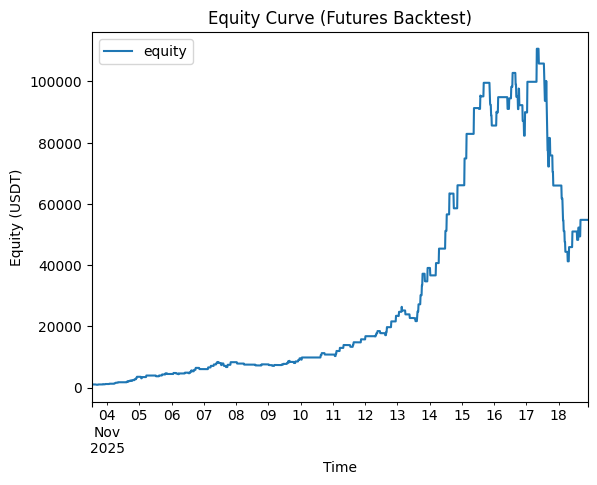

In [35]:
import matplotlib.pyplot as plt

equity_df.plot(title="Equity Curve (Futures Backtest)")
plt.xlabel("Time")
plt.ylabel("Equity (USDT)")
plt.show()


In [ ]:
trades_df.head(10)
